C:\Users\HP\AppData\Local\Temp\ipykernel_17816\2780799385.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
C:\Users\HP\AppData\Local\Temp\ipykernel_17816\2780799385.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time'].fillna(df['Time'].median(), inplace=True)


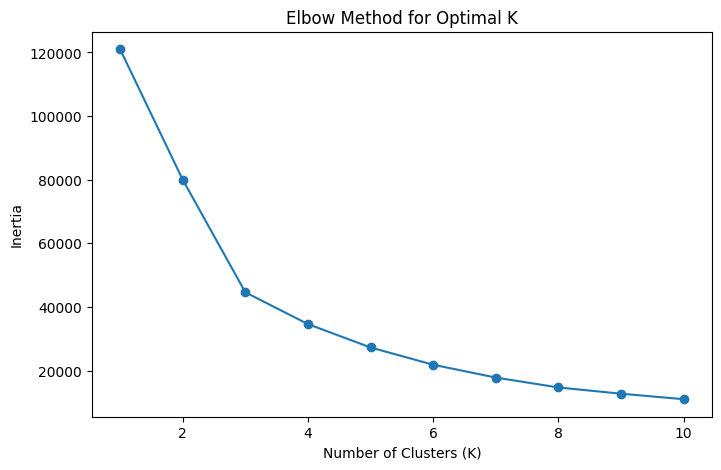

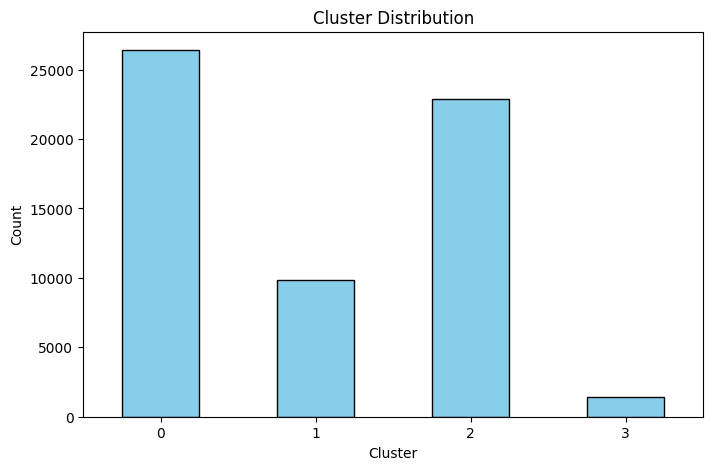

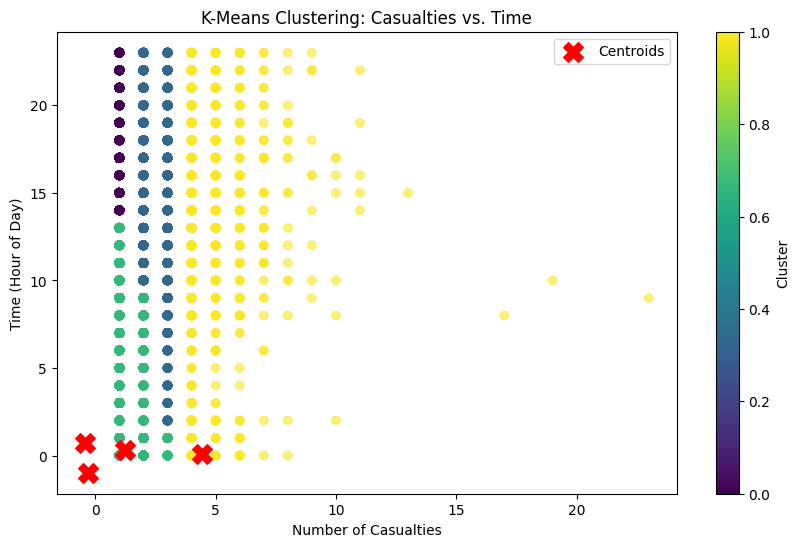

Inertia (Euclidean Distance): 34611.93415825436
Silhouette Score (Euclidean Distance): 0.5202042524397525
Adjusted Rand Index: 0.011518705596291071
   Number_of_Casualties  Time  Cluster
0                     1  17.0        0
1                     1  17.0        0
2                     1   0.0        2
3                     1  10.0        2
4                     1  21.0        0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Load dataset
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\RoadAccidentCurrent.xlsx")

# Convert 'Time' to numerical format (hour of the day)
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
df['Time'].fillna(df['Time'].median(), inplace=True)

# Select attributes for clustering
X = df[['Number_of_Casualties', 'Time']]  # Best attribute pair for clustering

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: ELBOW Method for Optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Step 2: K-Means Clustering (Using Optimal K)
optimal_k = 4  # Adjust based on Elbow Method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 3: Cluster Distribution (Histogram)
plt.figure(figsize=(8, 5))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.xticks(rotation=0)
plt.show()

# Step 4: Scatter Plot of Clusters
plt.figure(figsize=(10, 6))
plt.scatter(df['Number_of_Casualties'], df['Time'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.xlabel('Number of Casualties')
plt.ylabel('Time (Hour of Day)')
plt.title('K-Means Clustering: Casualties vs. Time')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

# Step 5: Cluster Analysis
inertia_value = kmeans.inertia_
silhouette_avg = silhouette_score(X_scaled, df['Cluster'], metric='euclidean')
ari = adjusted_rand_score(df['Accident_Severity'], df['Cluster'])  # Assuming 'Accident_Severity' is the target

print(f"Inertia (Euclidean Distance): {inertia_value}")
print(f"Silhouette Score (Euclidean Distance): {silhouette_avg}")
print(f"Adjusted Rand Index: {ari}")

# Step 6: Display Sample Clustered Data
print(df[['Number_of_Casualties', 'Time', 'Cluster']].head())